In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Read 8-bit grayscale image
img = cv2.imread("/content/Flower.jpg", cv2.IMREAD_GRAYSCALE)

In [ ]:
# (a) Brightness Improvement
bright = cv2.add(img, 50)

In [ ]:
# (b) Brightness Reduction
dark = cv2.subtract(img, 50)

In [ ]:
# (c) Thresholding
_, thresh = cv2.threshold(img, 128, 255, cv2.THRESH_BINARY)

In [ ]:
# (d) Negative Image
negative = 255 - img

In [ ]:
# (e) Log Transformation
img_float = img.astype(np.float32)

c = 255 / np.log(1 + 255)

log_image = c * np.log(1 + img_float)

log_image = cv2.normalize(
    log_image,
    None,
    0,
    255,
    cv2.NORM_MINMAX
)

log_image = np.uint8(log_image)

In [ ]:
# (f) Power Law (Gamma)
gamma = 0.5

power = np.power(img.astype(np.float32) / 255.0, gamma)
power = np.uint8(power * 255)

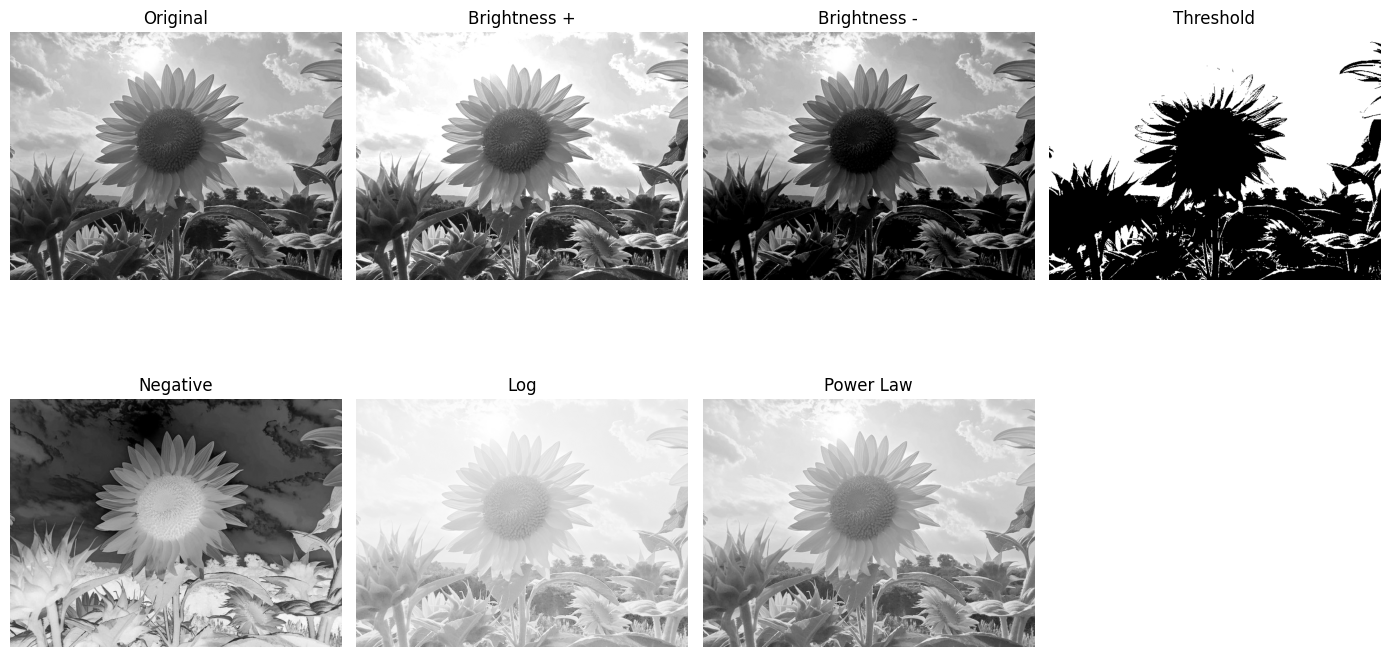

In [ ]:
titles = [
    "Original",
    "Brightness +",
    "Brightness -",
    "Threshold",
    "Negative",
    "Log",
    "Power Law"
]

images = [
    img,
    bright,
    dark,
    thresh,
    negative,
    log_image,
    power
]

plt.figure(figsize=(14,8))

for i in range(len(images)):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

Formula Used

# (a) Brightness Improvement
          s=r+C
where

 r = Original pixel

 C = Positive constant

# (b) Brightness Reduction
           s=r−C

# (c) Thresholding
       g(x,y)={ 255, f(x,y)≥T
             0, f(x,y)<T

where

 T = Threshold value (e.g., 128)

# (d) Negative Image
      s=L−1−r
For an 8-bit image

      L=256

Hence,

     s=255−r


# (e) Log Transformation

     s=clog(1+r)

where

    c=255/log(1+Maximum Pixel)





# (f) Power Law (Gamma) Transformation

        s=cr^γ

or in normalized form,

     s=255(r/255)^γ

where

γ<1 → Bright image

γ>1 → Dark image

γ=1 → Original image

If Gamma = 0.5 the image becomes brighter.

IF Gamma = 2.0 the image becomes darker.
